# Speech Emotion Recognition — Feature Extraction

This notebook covers the feature extraction pipeline for speech emotion recognition using the **RAVDESS** dataset.

**Pipeline overview:**
1. Load raw audio
2. Pre-emphasis filtering
3. Feature extraction: MFCC, Mel spectrogram, Δ/ΔΔ MFCC, ZCR, RMS

---
**Dataset:** [RAVDESS](https://zenodo.org/record/1188976)  
**Files used:** Actor 01 — Neutral (`03-01-01-01-01-01-01.wav`) and Angry (`03-01-05-01-01-01-01.wav`)

## 0. Imports

In [1]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
from scipy import signal

## 1. Load Audio

RAVDESS filename convention: `Modality-VocalChannel-Emotion-Intensity-Statement-Repetition-Actor.wav`  
Emotion codes: `01`=neutral, `05`=angry.

In [2]:
filename_neutral = "Audio_Speech_Actors_01-24/Actor_01/03-01-01-01-01-01-01.wav"
filename_angry   = "Audio_Speech_Actors_01-24/Actor_01/03-01-05-01-01-01-01.wav"

audio_neutral, sr = librosa.load(filename_neutral, sr=None)
audio_angry,   _  = librosa.load(filename_angry,   sr=None)

print(f"Sample rate : {sr} Hz")
print(f"Neutral duration: {len(audio_neutral)/sr:.2f} s  |  Angry duration: {len(audio_angry)/sr:.2f} s")

Sample rate : 48000 Hz
Neutral duration: 3.30 s  |  Angry duration: 3.87 s


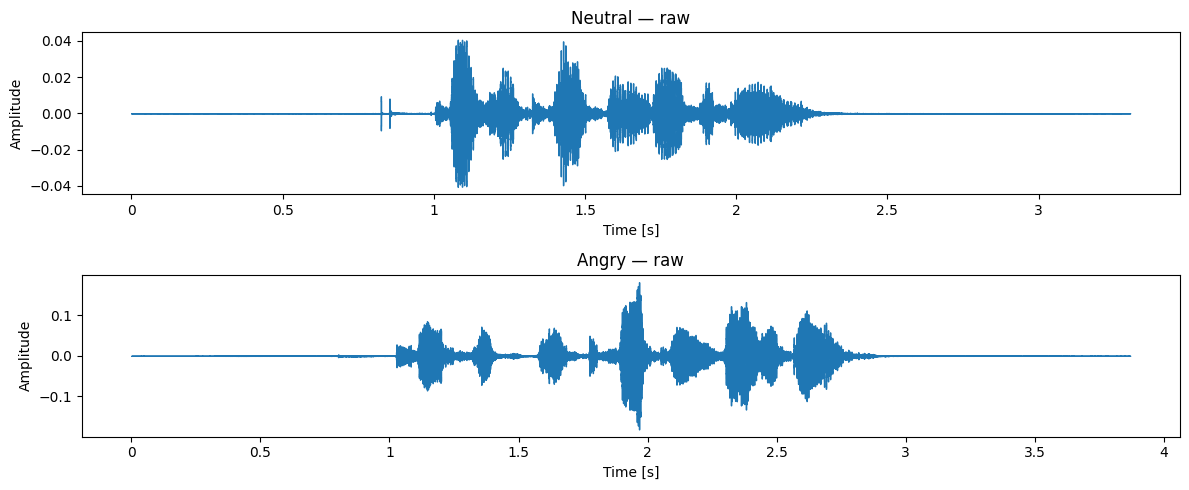

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=False)

librosa.display.waveshow(audio_neutral, sr=sr, ax=axes[0])
axes[0].set_title("Neutral — raw")
axes[0].set_xlabel("Time [s]")
axes[0].set_ylabel("Amplitude")

librosa.display.waveshow(audio_angry, sr=sr, ax=axes[1])
axes[1].set_title("Angry — raw")
axes[1].set_xlabel("Time [s]")
axes[1].set_ylabel("Amplitude")

plt.tight_layout()
plt.show()

## 2. Pre-Emphasis

First-order high-pass FIR filter: $y[n] = x[n] - \alpha \cdot x[n-1]$

**Why:** Speech has a spectral tilt of ~−6 dB/octave due to glottal source roll-off. Pre-emphasis compensates this, boosting high-frequency formants before analysis. Typical $\alpha \in [0.95, 0.97]$.

In [4]:
def pre_emphasis(sig, alpha=0.97):
    """Apply first-order pre-emphasis filter."""
    return signal.lfilter([1, -alpha], [1], sig)

alpha = 0.97
emphd_neutral = pre_emphasis(audio_neutral, alpha)
emphd_angry   = pre_emphasis(audio_angry,   alpha)

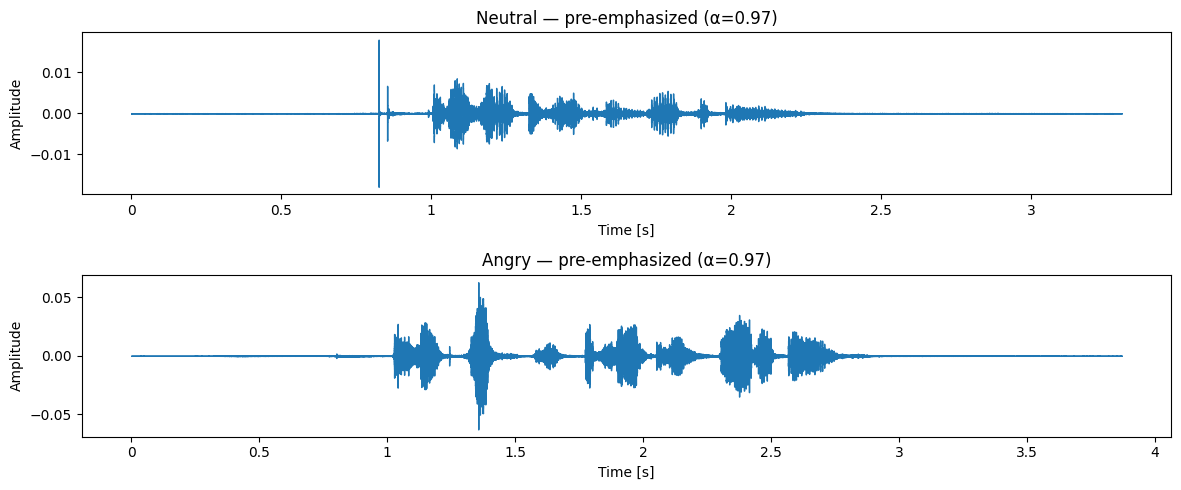

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=False)

librosa.display.waveshow(emphd_neutral, sr=sr, ax=axes[0])
axes[0].set_title(f"Neutral — pre-emphasized (α={alpha})")
axes[0].set_xlabel("Time [s]")
axes[0].set_ylabel("Amplitude")

librosa.display.waveshow(emphd_angry, sr=sr, ax=axes[1])
axes[1].set_title(f"Angry — pre-emphasized (α={alpha})")
axes[1].set_xlabel("Time [s]")
axes[1].set_ylabel("Amplitude")

plt.tight_layout()
plt.show()

## 3. Framing Parameters

Speech is non-stationary globally but approximately stationary over short windows (~20–40 ms). We slice it into overlapping frames and treat each frame as a stationary segment.

| Parameter | Value | Notes |
|---|---|---|
| `frame_time` | 25 ms | Standard for speech; ~1–2 pitch periods |
| `frame_stride` | 10 ms | 60% overlap — good time resolution |
| `n_fft` | 2048 | Next power-of-2 above `frame_length` (1200 samples) |

In [6]:
frame_time   = 0.025          # 25 ms
frame_stride = 0.010          # 10 ms
n_fft        = 2048

frame_length = int(frame_time   * sr)   # samples per frame
frame_step   = int(frame_stride * sr)   # hop in samples

print(f"Frame length : {frame_length} samples ({frame_time*1000:.0f} ms)")
print(f"Frame step   : {frame_step} samples ({frame_stride*1000:.0f} ms)")
print(f"n_fft        : {n_fft}")

Frame length : 1200 samples (25 ms)
Frame step   : 480 samples (10 ms)
n_fft        : 2048


## 4. MFCC — Mel-Frequency Cepstral Coefficients

**Pipeline:** STFT → Mel filterbank (warped to perceptual scale) → log → DCT → coefficients

The DCT decorrelates the filterbank energies; the resulting coefficients compactly represent the spectral envelope (vocal tract shape). First coefficient (C0) encodes overall energy; higher coefficients capture finer spectral detail.

Reference: [Haytham Fayek — Speech Processing for ML](https://haythamfayek.com/2016/04/21/speech-processing-for-machine-learning.html)

In [7]:
n_mfcc = 40

mfcc_neutral = librosa.feature.mfcc(
    y=emphd_neutral, sr=sr,
    n_mfcc=n_mfcc, n_fft=n_fft,
    win_length=frame_length, hop_length=frame_step
)

mfcc_angry = librosa.feature.mfcc(
    y=emphd_angry, sr=sr,
    n_mfcc=n_mfcc, n_fft=n_fft,
    win_length=frame_length, hop_length=frame_step
)

print(f"MFCC shape (coefficients × frames): {mfcc_neutral.shape}")

MFCC shape (coefficients × frames): (40, 331)


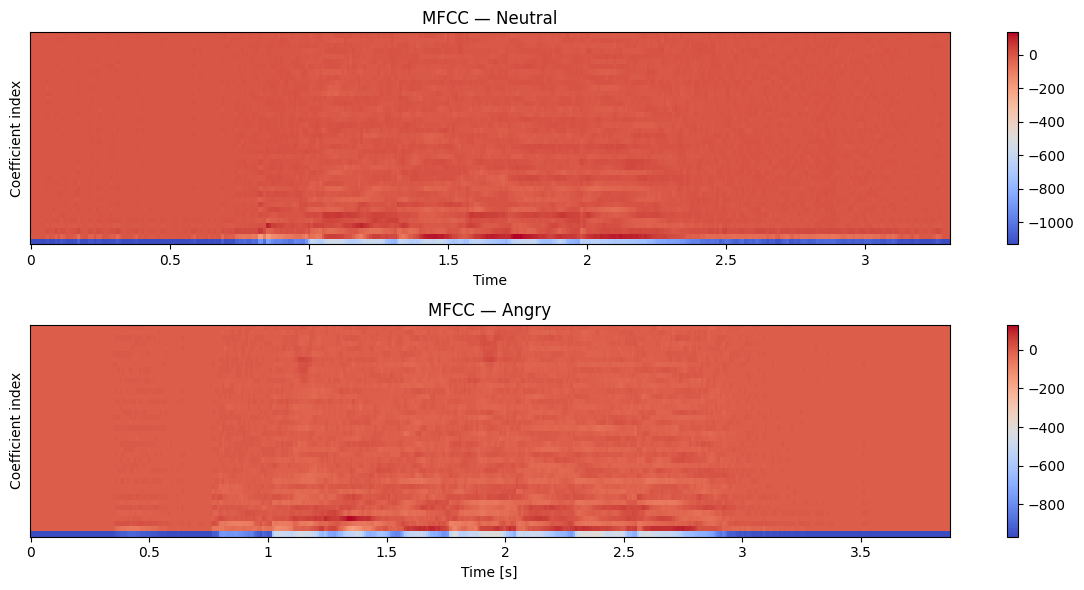

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6))

img0 = librosa.display.specshow(mfcc_neutral, sr=sr, hop_length=frame_step,
                                 x_axis='time', ax=axes[0])
fig.colorbar(img0, ax=axes[0])
axes[0].set_title("MFCC — Neutral")
axes[0].set_ylabel("Coefficient index")

img1 = librosa.display.specshow(mfcc_angry, sr=sr, hop_length=frame_step,
                                 x_axis='time', ax=axes[1])
fig.colorbar(img1, ax=axes[1])
axes[1].set_title("MFCC — Angry")
axes[1].set_ylabel("Coefficient index")
axes[1].set_xlabel("Time [s]")

plt.tight_layout()
plt.show()

## 5. Mel Spectrogram

Power spectrogram with frequency axis warped to the Mel scale — approximates the non-linear frequency resolution of the auditory system (~linear below 1 kHz, logarithmic above). Unlike MFCCs, this retains spatial frequency structure useful for CNN-based models.

In [9]:
mel_neutral = librosa.feature.melspectrogram(
    y=emphd_neutral, sr=sr,
    n_fft=n_fft, win_length=frame_length, hop_length=frame_step
)
mel_angry = librosa.feature.melspectrogram(
    y=emphd_angry, sr=sr,
    n_fft=n_fft, win_length=frame_length, hop_length=frame_step
)

# Convert power → dB for perceptually meaningful visualization
mel_neutral_db = librosa.power_to_db(mel_neutral, ref=np.max)
mel_angry_db   = librosa.power_to_db(mel_angry,   ref=np.max)

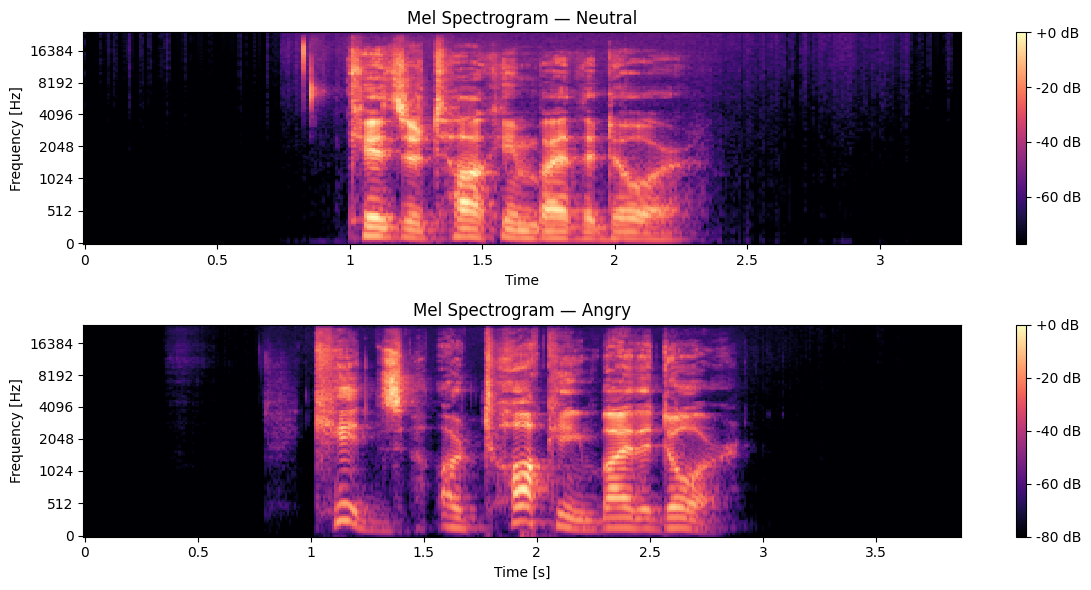

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6))

img0 = librosa.display.specshow(mel_neutral_db, sr=sr, hop_length=frame_step,
                                 x_axis='time', y_axis='mel', ax=axes[0])
fig.colorbar(img0, ax=axes[0], format='%+2.0f dB')
axes[0].set_title("Mel Spectrogram — Neutral")
axes[0].set_ylabel("Frequency [Hz]")

img1 = librosa.display.specshow(mel_angry_db, sr=sr, hop_length=frame_step,
                                 x_axis='time', y_axis='mel', ax=axes[1])
fig.colorbar(img1, ax=axes[1], format='%+2.0f dB')
axes[1].set_title("Mel Spectrogram — Angry")
axes[1].set_ylabel("Frequency [Hz]")
axes[1].set_xlabel("Time [s]")

plt.tight_layout()
plt.show()

## 6. Delta & Delta-Delta MFCC

**Δ (delta):** Frame-to-frame derivative of MFCCs — captures velocity of spectral change, reflecting prosodic dynamics (rhythm, stress, intonation).  
**ΔΔ (delta-delta):** Second-order derivative — captures acceleration of those changes.

Concatenating `[MFCC | Δ | ΔΔ]` is the standard 120-dim feature vector for classical ASR/SER pipelines.

In [11]:
delta_neutral       = librosa.feature.delta(mfcc_neutral)
delta_delta_neutral = librosa.feature.delta(mfcc_neutral, order=2)

delta_angry         = librosa.feature.delta(mfcc_angry)
delta_delta_angry   = librosa.feature.delta(mfcc_angry,   order=2)

print(f"Δ shape: {delta_neutral.shape}  |  ΔΔ shape: {delta_delta_neutral.shape}")

Δ shape: (40, 331)  |  ΔΔ shape: (40, 331)


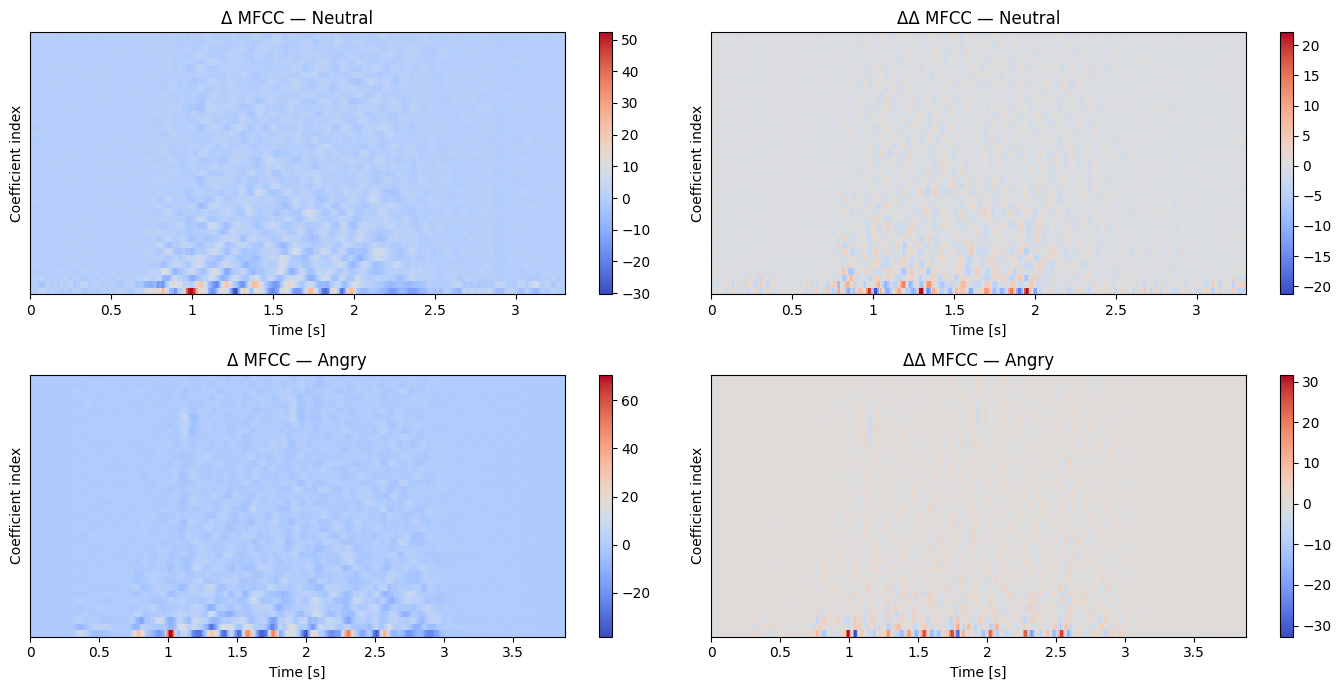

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 7))

for ax, data, title in zip(
    axes.flat,
    [delta_neutral, delta_delta_neutral, delta_angry, delta_delta_angry],
    ["Δ MFCC — Neutral", "ΔΔ MFCC — Neutral", "Δ MFCC — Angry", "ΔΔ MFCC — Angry"]
):
    img = librosa.display.specshow(data, sr=sr, hop_length=frame_step, x_axis='time', ax=ax)
    fig.colorbar(img, ax=ax)
    ax.set_title(title)
    ax.set_ylabel("Coefficient index")
    ax.set_xlabel("Time [s]")

plt.tight_layout()
plt.show()

## 7. Zero Crossing Rate (ZCR)

Number of times the signal changes sign within a frame, normalized by frame length.

$$\text{ZCR}[m] = \frac{1}{N} \sum_{n=1}^{N} \mathbb{1}\bigl[x_m[n] \cdot x_m[n-1] < 0\bigr]$$

High ZCR → unvoiced segments (fricatives, silence).  
Low ZCR → voiced segments (vowels, nasals).  
Useful for voiced/unvoiced segmentation and as a rough noise indicator.

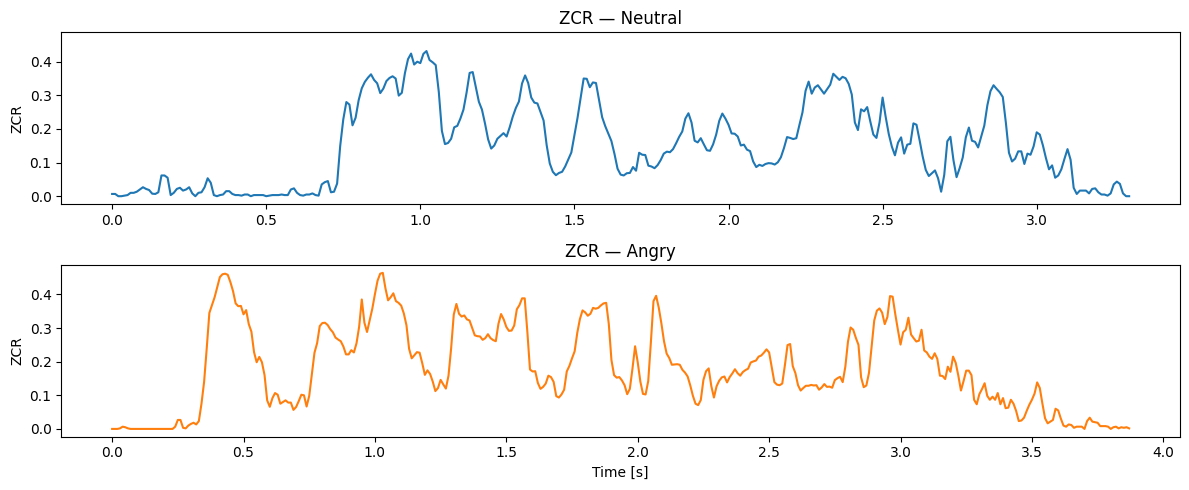

In [13]:
zcr_neutral = librosa.feature.zero_crossing_rate(emphd_neutral, frame_length=frame_length, hop_length=frame_step)
zcr_angry   = librosa.feature.zero_crossing_rate(emphd_angry,   frame_length=frame_length, hop_length=frame_step)

t_neutral = librosa.frames_to_time(np.arange(zcr_neutral.shape[1]), sr=sr, hop_length=frame_step)
t_angry   = librosa.frames_to_time(np.arange(zcr_angry.shape[1]),   sr=sr, hop_length=frame_step)

fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharey=True)

axes[0].plot(t_neutral, zcr_neutral[0])
axes[0].set_title("ZCR — Neutral")
axes[0].set_ylabel("ZCR")

axes[1].plot(t_angry, zcr_angry[0], color='tab:orange')
axes[1].set_title("ZCR — Angry")
axes[1].set_ylabel("ZCR")
axes[1].set_xlabel("Time [s]")

plt.tight_layout()
plt.show()

## 8. RMS Energy

Root mean square of the signal amplitude per frame — a proxy for short-time energy.

$$\text{RMS}[m] = \sqrt{\frac{1}{N} \sum_{n=0}^{N-1} x_m[n]^2}$$

Angry speech typically shows higher and more variable RMS than neutral. Useful for activity detection (VAD) and as an emotion discriminator.

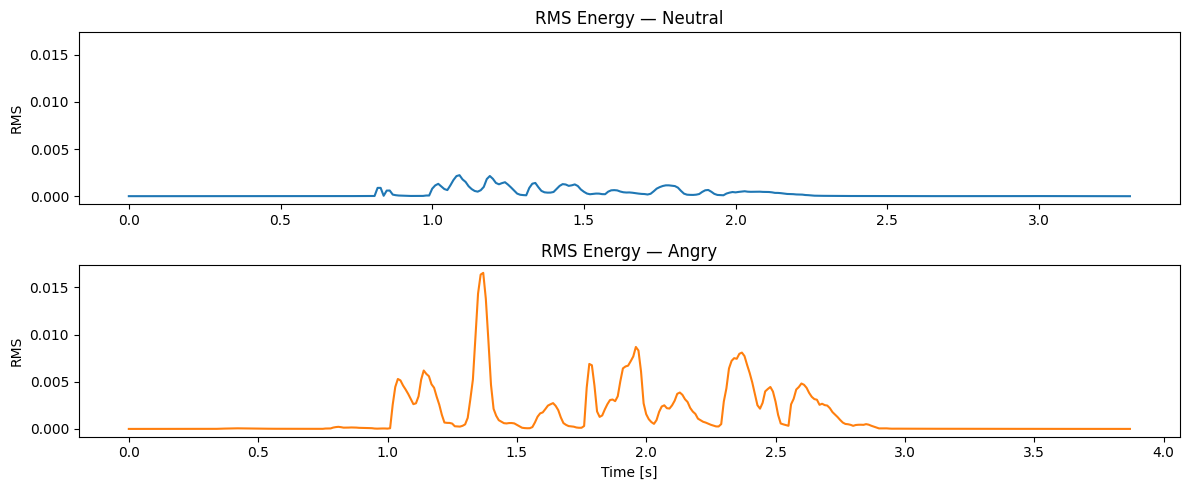

In [14]:
rms_neutral = librosa.feature.rms(y=emphd_neutral, frame_length=frame_length, hop_length=frame_step)
rms_angry   = librosa.feature.rms(y=emphd_angry,   frame_length=frame_length, hop_length=frame_step)

t_rms_neutral = librosa.frames_to_time(np.arange(rms_neutral.shape[1]), sr=sr, hop_length=frame_step)
t_rms_angry   = librosa.frames_to_time(np.arange(rms_angry.shape[1]),   sr=sr, hop_length=frame_step)

fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharey=True)

axes[0].plot(t_rms_neutral, rms_neutral[0])
axes[0].set_title("RMS Energy — Neutral")
axes[0].set_ylabel("RMS")

axes[1].plot(t_rms_angry, rms_angry[0], color='tab:orange')
axes[1].set_title("RMS Energy — Angry")
axes[1].set_ylabel("RMS")
axes[1].set_xlabel("Time [s]")

plt.tight_layout()
plt.show()

## 9. Feature Summary

| Feature | Shape (per clip) | What it encodes |
|---|---|---|
| MFCC | `(40, T)` | Spectral envelope / vocal tract shape |
| Δ MFCC | `(40, T)` | Velocity of spectral change (prosody) |
| ΔΔ MFCC | `(40, T)` | Acceleration of spectral change |
| Mel spectrogram | `(128, T)` | Full spectral content on perceptual scale |
| ZCR | `(1, T)` | Voiced/unvoiced discrimination |
| RMS | `(1, T)` | Short-time energy / loudness |

Typical next steps: aggregate over time (mean/std pooling), concatenate into a fixed-length vector, then feed to a classifier (SVM, MLP) — or keep the 2D arrays and use a CNN/RNN.

In [15]:
# Example: build a simple aggregated feature vector (mean + std over time axis)
def aggregate_features(mfcc, delta, delta_delta, zcr, rms):
    feats = np.concatenate([
        mfcc.mean(axis=1), mfcc.std(axis=1),
        delta.mean(axis=1), delta.std(axis=1),
        delta_delta.mean(axis=1), delta_delta.std(axis=1),
        zcr.mean(axis=1), zcr.std(axis=1),
        rms.mean(axis=1), rms.std(axis=1),
    ])
    return feats

vec_neutral = aggregate_features(mfcc_neutral, delta_neutral, delta_delta_neutral, zcr_neutral, rms_neutral)
vec_angry   = aggregate_features(mfcc_angry,   delta_angry,   delta_delta_angry,   zcr_angry,   rms_angry)

print(f"Feature vector length: {vec_neutral.shape[0]}")

Feature vector length: 244
